In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, f_classif, RFE
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap
from umap import UMAP
from sklearn.metrics import classification_report, r2_score
from sklearn.neighbors import KNeighborsClassifier

c:\Users\Slava\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Иморт данных

In [2]:
reg_df = pd.read_csv("../data/Regression_wine_quality_filtered.csv", sep=",", encoding="utf-8", index_col=0)
clf_df = pd.read_csv("../data/Classification_smoke_detectors_filtered.csv", sep=",", encoding="utf-8", index_col=0)

In [3]:
X_reg = reg_df.drop('quality', axis=1)
y_reg = reg_df['quality']

X_clf = clf_df.drop('Fire Alarm', axis=1)
y_clf = clf_df['Fire Alarm']

**Скалировние**

In [4]:
scaler = StandardScaler()

In [5]:
X_scaled_r = scaler.fit_transform(X_reg)
X_scaled_r = pd.DataFrame(X_scaled_r, columns=X_reg.columns)
X_scaled_r.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246


In [6]:
X_scaled_c = scaler.fit_transform(X_clf)
X_scaled_c = pd.DataFrame(X_scaled_c, columns=X_clf.columns)
X_scaled_c.head()

,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT
0,0.280087,0.996015,-0.248618,-0.141312,-2.337045,-2.025006,0.831989,-0.109043,-0.093081,-0.115215,-0.09165,-0.073889,-1.383476
1,0.281133,0.918066,-0.248618,-0.141312,-2.193815,-1.810079,0.838751,-0.109043,-0.093081,-0.115215,-0.09165,-0.073889,-1.383344
2,0.282108,0.837858,-0.248618,-0.141312,-2.087311,-1.624683,0.834243,-0.109043,-0.093081,-0.115215,-0.09165,-0.073889,-1.383212
3,0.283154,0.761039,-0.248618,-0.141312,-2.028549,-1.485227,0.832740,-0.109043,-0.093081,-0.115215,-0.09165,-0.073889,-1.383081
4,0.284200,0.694388,-0.248618,-0.141312,-1.980806,-1.367099,0.838751,-0.109043,-0.093081,-0.115215,-0.09165,-0.073889,-1.382949


**Функция для тестирования**

In [7]:
def test_func(X, y, model, metric_func, feature_selector=None):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if feature_selector == None:
        print(f'Количество признаков {X.shape[1]}')
    else:
        print(f'Признаки {feature_selector.get_support(indices=True)}, Количество {X.shape[1]}')
        
    print(f'Метрика {metric_func(y_test, y_pred)}')
    

## Результаты без понижения размерности

In [8]:
test_func(X_scaled_r, y_reg, LinearRegression(), r2_score)

Количество признаков 11
Метрика 0.4031803412796219


In [9]:
test_func(X_scaled_c, y_clf, KNeighborsClassifier(), classification_report)

Количество признаков 13
Метрика               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3594
         1.0       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



## VarianceThreshold

In [10]:
vt_r = VarianceThreshold(threshold=1)
X_vt_r = vt_r.fit_transform(X_scaled_r)

test_func(X_vt_r, y_reg, LinearRegression(), r2_score, vt_r)

Признаки [0 1 3 4], Количество 4
Метрика 0.1982331572207109


In [11]:
vt_c = VarianceThreshold(threshold=1)
X_vt_c = vt_c.fit_transform(X_scaled_c)

test_func(X_vt_c, y_clf, KNeighborsClassifier(), classification_report, vt_c)

Признаки [2 3 6], Количество 3
Метрика               precision    recall  f1-score   support

         0.0       0.96      0.93      0.94      3594
         1.0       0.97      0.98      0.98      8932

    accuracy                           0.97     12526
   macro avg       0.96      0.96      0.96     12526
weighted avg       0.97      0.97      0.97     12526



## SelectKBest

In [12]:
skb_r = SelectKBest(f_regression, k=3)
X_skb_r = skb_r.fit_transform(X_scaled_r,y_reg)

test_func(X_skb_r, y_reg, LinearRegression(), r2_score, skb_r)

Признаки [ 1  9 10], Количество 3
Метрика 0.387032916341121


In [13]:
skb_c = SelectKBest(f_classif, k=2)
X_skb_c = skb_c.fit_transform(X_scaled_c,y_clf)

test_func(X_skb_c, y_clf, KNeighborsClassifier(), classification_report, skb_c)

Признаки [ 1 12], Количество 2
Метрика               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3594
         1.0       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      0.99      1.00     12526
weighted avg       1.00      1.00      1.00     12526



## RFE

In [14]:
rfe_r = RFE(LinearRegression(), n_features_to_select=3)
X_rfe_r = rfe_r.fit_transform(X_scaled_r, y_reg)

test_func(X_rfe_r, y_reg, LinearRegression(), r2_score, rfe_r)

Признаки [ 1  9 10], Количество 3
Метрика 0.387032916341121


In [15]:
rfe_c = RFE(LogisticRegression(), n_features_to_select=3)
X_rfe_c = rfe_c.fit_transform(X_scaled_c, y_clf)

test_func(X_rfe_c, y_clf, KNeighborsClassifier(), classification_report, rfe_c)

Признаки [ 2  3 12], Количество 3
Метрика               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      3594
         1.0       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



## PCA

In [16]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_r)

test_func(X_pca, y_reg, LinearRegression(), r2_score)

Количество признаков 3
Метрика 0.36939123123140827


In [17]:
pca_c = PCA(n_components=2)
X_pca_c = pca_c.fit_transform(X_scaled_c)

test_func(X_pca_c, y_clf, KNeighborsClassifier(), classification_report)

Количество признаков 2
Метрика               precision    recall  f1-score   support

         0.0       0.92      0.92      0.92      3594
         1.0       0.97      0.97      0.97      8932

    accuracy                           0.95     12526
   macro avg       0.95      0.94      0.94     12526
weighted avg       0.95      0.95      0.95     12526



## KernelPCA

In [18]:
kernel_configs = {
    'poly': {'kernel': 'poly', 'degree': 2, 'coef0': 1},
    'rbf': {'kernel': 'rbf', 'gamma': 0.1},
    'sigmoid': {'kernel': 'sigmoid', 'gamma': 0.1, 'coef0': 1}
}

In [19]:
for kernel_name, params in kernel_configs.items():
    print(f"\nKernel: {kernel_name}")
    kpca = KernelPCA(n_components=3, **params)
    X_kpca = kpca.fit_transform(X_scaled_r)
    test_func(X_kpca, y_reg, LinearRegression(), r2_score)


Kernel: poly
Количество признаков 3
Метрика 0.032743918475917955

Kernel: rbf
Количество признаков 3
Метрика 0.27515474201324874

Kernel: sigmoid
Количество признаков 3
Метрика 0.3630277556074045


In [20]:
X_cut = X_scaled_c.head(8000)
y_cut = y_clf.head(8000)

In [21]:
for kernel_name, params in kernel_configs.items():
    print(f"\nKernel: {kernel_name}")
    kpca_c = KernelPCA(n_components=3, **params)
    X_kpca_c = kpca_c.fit_transform(X_cut)
    test_func(X_kpca_c, y_cut, KNeighborsClassifier(), classification_report)


Kernel: poly
Количество признаков 3
Метрика               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       651
         1.0       1.00      0.99      1.00       949

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600


Kernel: rbf
Количество признаков 3
Метрика               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       651
         1.0       1.00      0.99      1.00       949

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600


Kernel: sigmoid
Количество признаков 3
Метрика               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       651
         1.0       1.00      0.99      1.00       949

    accuracy                           1.00  

## TSNE

In [22]:
tsne = TSNE(n_components=3)
X_tsne = tsne.fit_transform(X_scaled_r)

test_func(X_tsne, y_reg, LinearRegression(), r2_score)

Количество признаков 3
Метрика 0.24740463495254517


In [23]:
tsne_c = TSNE(n_components=2)
X_tsne_c = tsne_c.fit_transform(X_cut)

test_func(X_tsne_c, y_cut, KNeighborsClassifier(), classification_report)

Количество признаков 2
Метрика               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       651
         1.0       1.00      0.99      1.00       949

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



## Isomap

In [24]:
isomap = Isomap(n_components=3, n_neighbors=5)
X_isomap = isomap.fit_transform(X_scaled_r)

test_func(X_isomap, y_reg, LinearRegression(), r2_score)

Количество признаков 3
Метрика 0.34343907223498016


In [25]:
isomap_c = Isomap(n_components=2, n_neighbors=5)
X_isomap_c = isomap_c.fit_transform(X_cut)

test_func(X_isomap_c, y_cut, KNeighborsClassifier(), classification_report)

Количество признаков 2
Метрика               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       651
         1.0       1.00      1.00      1.00       949

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



## UMAP

In [26]:
umap_reducer = UMAP(n_components=3)
X_umap = umap_reducer.fit_transform(X_scaled_r)

test_func(X_umap, y_reg, LinearRegression(), r2_score)

Количество признаков 3
Метрика 0.2767066955566406


In [27]:
umap_reducer_c = UMAP(n_components=2)
X_umap_c = umap_reducer_c.fit_transform(X_scaled_c)

test_func(X_umap_c, y_clf, KNeighborsClassifier(), classification_report)

Количество признаков 2
Метрика               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3594
         1.0       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526



Для уменьшения размерности данных регрессии лучше всего подошли методы SelectKBest и RFE. С уменьшением размерности для данных классификации все алгоритмы справились одинаково хорошо, но время выполнения KernelPCA, TSNE, Isomap и UMAP слишком велико.   

## Кастомный PCA

In [34]:
from custom_pca import CustomPCA
import matplotlib.pyplot as plt

In [31]:
pca = CustomPCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_c)

In [32]:
test_func(X_pca, y_clf, KNeighborsClassifier(), classification_report)

Количество признаков 2
Метрика               precision    recall  f1-score   support

         0.0       0.92      0.92      0.92      3594
         1.0       0.97      0.97      0.97      8932

    accuracy                           0.95     12526
   macro avg       0.95      0.94      0.94     12526
weighted avg       0.95      0.95      0.95     12526



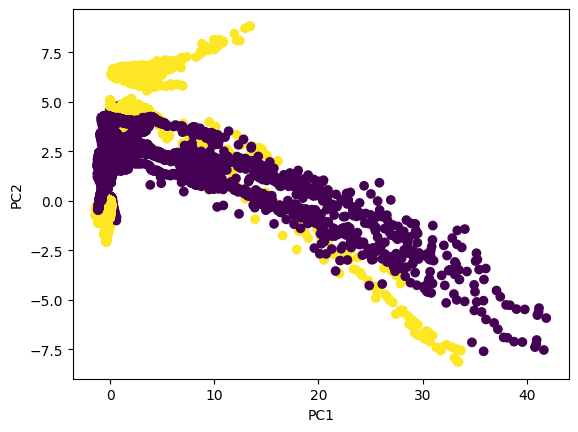

In [36]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_clf, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [37]:
from k_means_custom import KMeansCustom

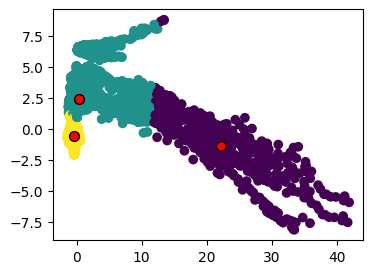

In [40]:
custom_km = KMeansCustom()
custom_km.fit(X_pca)

fig, ax = plt.subplots(figsize=(4, 3)) 
ax.scatter(X_pca[:,0], X_pca[:,1], c=custom_km.labels_, cmap='viridis')
ax.scatter(custom_km.centroids[:, 0], custom_km.centroids[:, 1], c='red', marker='.', s=200, edgecolors='black')

plt.show()